In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

sns.set_theme(style='whitegrid')

In [12]:
aisles         = pd.read_csv('./datasets/aisles.csv')
departments    = pd.read_csv('./datasets/departments.csv')
products       = pd.read_csv('./datasets/products.csv')
orders         = pd.read_csv('./datasets/orders.csv')
order_products = pd.read_csv('./datasets/order_products.csv')

## EDA

### Quelles sont les pics d'affluences dans la semaine ?

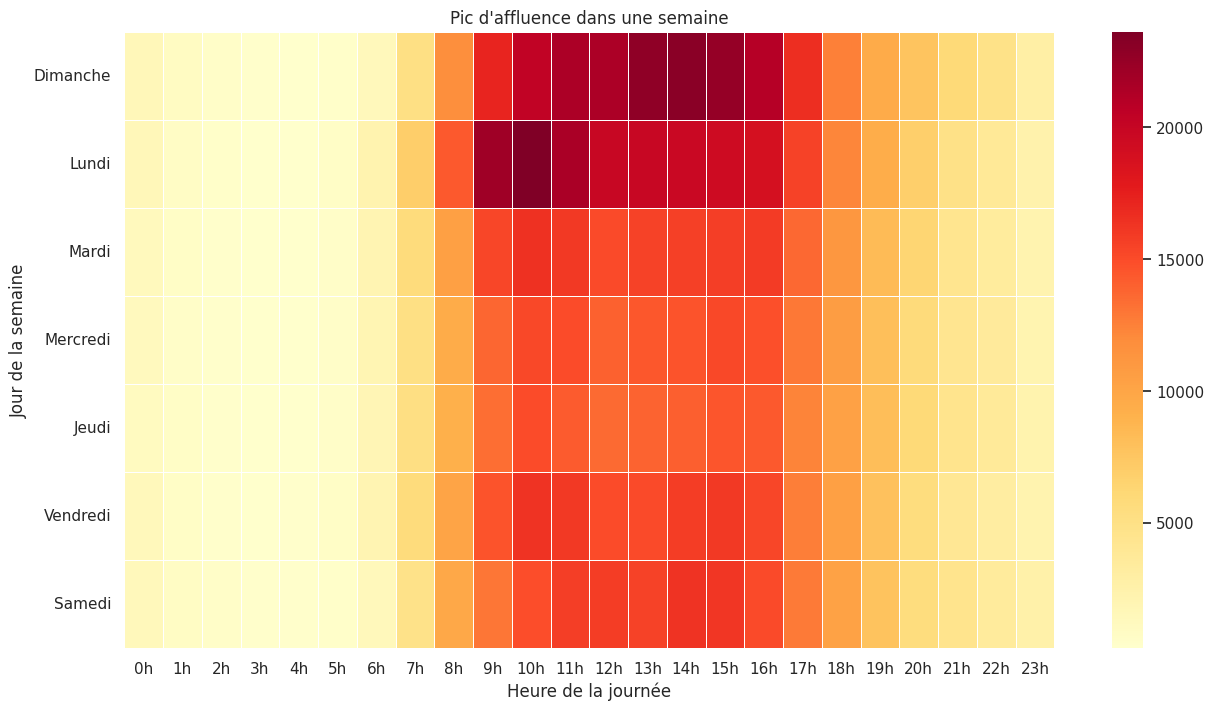

In [13]:

cols = ['order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']


orders = pd.read_csv('./datasets/orders.csv', skiprows=1, names=cols)
group_day_hour=orders.groupby(["order_dow", "order_hour_of_day"])["order_id"].count().reset_index()

orders_tab=group_day_hour.pivot(index='order_dow', columns='order_hour_of_day', values='order_id')


plt.figure(figsize=(15, 8))
sns.heatmap(orders_tab, cmap="YlOrRd", linewidths=.5)

plt.yticks(ticks=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5], 
           labels=['Dimanche', 'Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi'], 
           rotation=0)


heures_positions = [i + 0.5 for i in range(24)]
heures_labels = [f"{i}h" for i in range(24)]
plt.xticks(ticks=heures_positions, labels=heures_labels, rotation=0)


plt.title("Pic d'affluence dans une semaine")
plt.xlabel("Heure de la journée")
plt.ylabel("Jour de la semaine")
plt.show()


Observations : 
-  L'affluence est plus forte particulièrement le dimanche entre 13 heures et 15 heures.
-  L'affluence est forte aussi le lundi vers 10 heures.

Améliorations : 
-  Gérer le stock avant pour éviter des ruptures.
-  Mettre plus de personnel à ces moments-la.

In [14]:


#orders_tab.describe()

### Produit le plus souvent mis en premier dans le panier

/tmp/ipykernel_126298/3614065548.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top, x='count', y='product_name', palette='viridis')


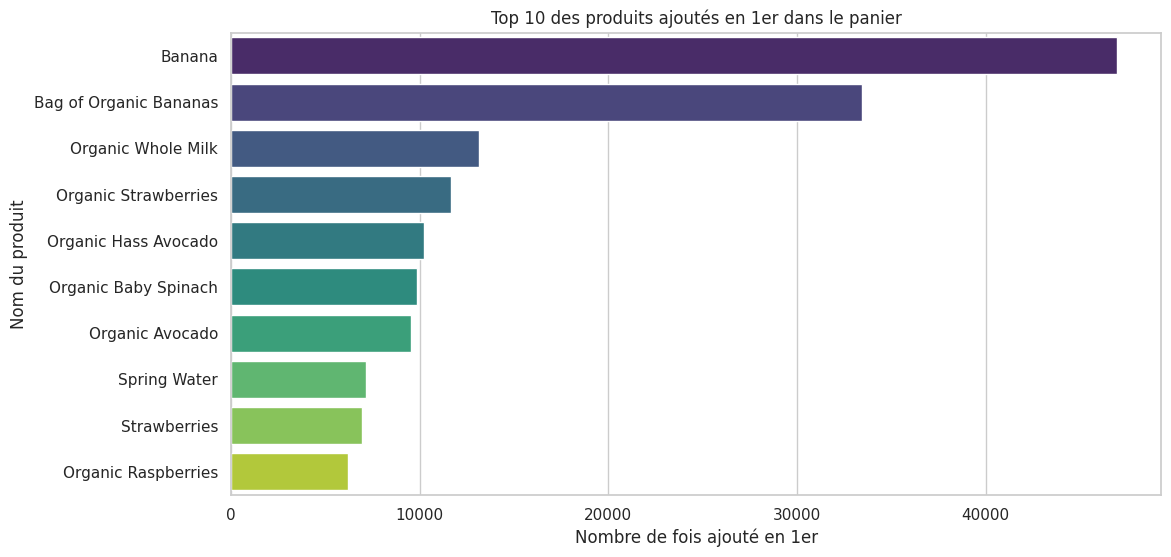

In [15]:
cart_first=order_products[order_products['add_to_cart_order']==1]
count_first_product=cart_first['product_id'].value_counts().reset_index()
count_first_product.columns=['product_id', 'count']



top_merged=pd.merge(count_first_product, products[['product_id', 'product_name']], on='product_id', how='left')
top=top_merged.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top, x='count', y='product_name', palette='viridis')


plt.title("Top 10 des produits ajoutés en 1er dans le panier")
plt.xlabel("Nombre de fois ajouté en 1er")
plt.ylabel("Nom du produit")
plt.show()

Observations :
-  Le produit le plus mis en 1er dans le panier est la banane.
-  Les 10 premiers produits le plus mis en premier dans le panier sont majoritairement des fruits et légumes.
-  Parmi les 10 produits, 7 sont d'origine biologiques.
-  Ce sont une majorité de produits frais qu'on rachète souvent.
-  L'écart entre le 1er et le second est important.

Améliorations : 
-  Améliorer la visibilité de ces produits pour éviter au client de les chercher trop longtemps.
-  S'assurer que ces produits ne sont jamais en rupture de stock.
-  Elargir la part de produits biologiques.

### Quelle est la fréquence à laquelle les clients reviennent faire leurs courses

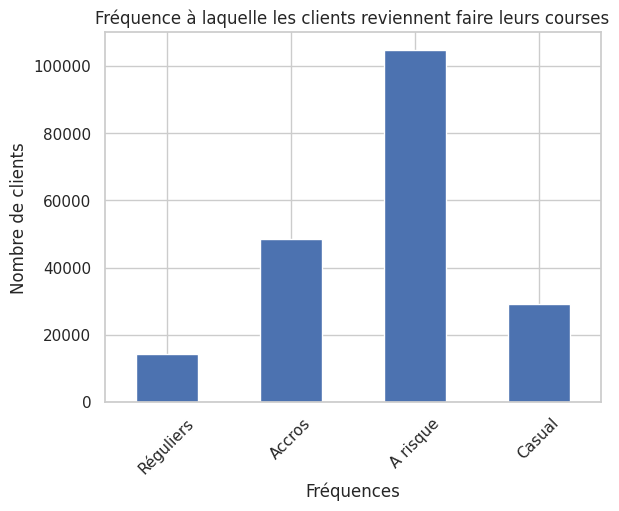

In [16]:
df_reorders = orders.dropna(subset=['days_since_prior_order'])
freq = df_reorders['days_since_prior_order'].mean()
freq_by_custmer = df_reorders.groupby('user_id')['days_since_prior_order'].mean()

bornes = [0, 5, 10, 25, float('inf')]
etiq = ["Réguliers", "Accros", "A risque", "Casual"]
segments = pd.cut(freq_by_custmer, bins=bornes, labels=etiq)
count = segments.value_counts()
count.reindex(etiq).plot(kind='bar')
plt.title("Fréquence à laquelle les clients reviennent faire leurs courses")
plt.xlabel("Fréquences")
plt.ylabel("Nombre de clients")
plt.xticks(rotation=45)
plt.show()

### Quels rayons finissent le plus souvent en fin de panier ?

/tmp/ipykernel_126298/3891551319.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


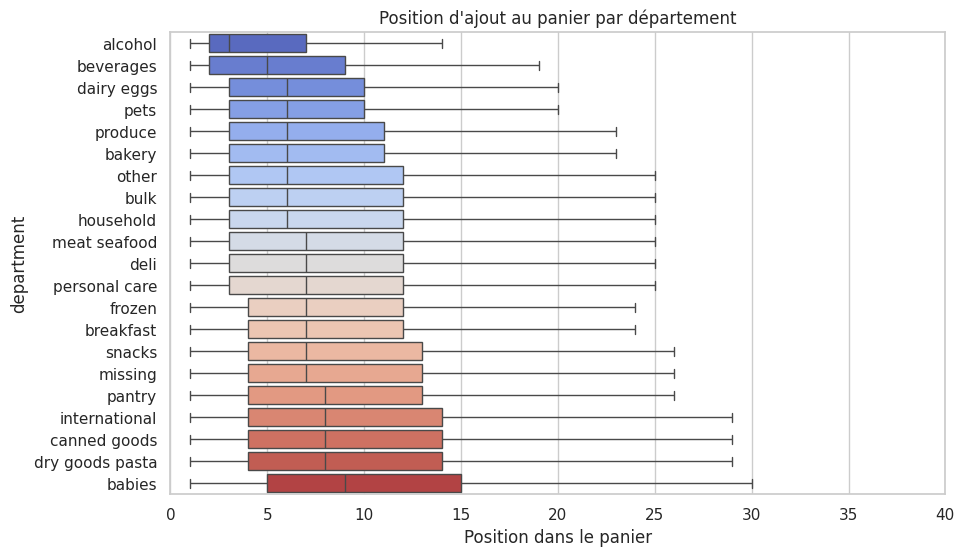

In [17]:
product_merged=pd.merge(order_products, products[['product_id', 'department_id']], on='product_id', how='left')
name_merged=pd.merge(product_merged, departments, on='department_id', how='left')

group_department=name_merged.groupby("department")["add_to_cart_order"].mean().reset_index()
group_department = group_department.sort_values(by="add_to_cart_order")


plt.figure(figsize=(10, 6))
sns.boxplot(
    data=name_merged, 
    x='add_to_cart_order', 
    y='department', 
    order=group_department['department'],
    palette='coolwarm',
    showfliers=False
)

plt.title("Position d'ajout au panier par département")
plt.xlabel("Position dans le panier")

plt.xlim(0, 40) 

plt.show()

Compréhension du graphique (Boxplot) :
-  La partie avant la boîte de couleur représente 25% des clients les plus rapides à mettre l'article dans le panier.
-  La boîte représente 50 % des clients.
-  Après la boîte c'est les 25% restants les plus lents.
-  L'axe x donne l'ordre et les boîtes la proportion de clients qui le fait à ce moment-la.
-  Le trait au milieu de la boîte représente la médiane le client 50, indique la position typique du client du milieu.
-  Les traits noirs extérieurs représentent les extrêmes.

Avantage :
-  Montre l'étendue des comportements, permet de voir si les clients agissent de la même manière.
-  Une moyenne aurait été faussé par des comportements rares, la médiane observe le comportement d'un client typique.
-  Plusieurs d'informations d'un coup.
-  Plus nuancé qu'un barplot.

Observations : 
-  Les achats le plus souvent fait en 1er sont dans les rayons alcools, boissons et crémerie. Presque tout le monde commence ses courses par ces produits.
-  Les articles d'épicerie et pour bébés sont ajoutés beaucoup plus tard, ce sont des achats complémentaires.
-  Plus on descend dans le graphique plus les boîtes sont larges ce qui montre une grande variabilité dans les habitudes contrairement à l'alcool.

Améliorations :
-  Mettre en évidence les produits le plus souvent mis en 1er afin de faire gagner du temps au client.
-  Proposer les produits d'épiceries juste avant le paiement pour qu'il achète avec impulsion.
-  Améliorer le parcours client.

## Modèles